<a href="https://colab.research.google.com/github/tyangdon/QVI-Retail-Analytics-project/blob/main/QVI_Quantum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QVI Retail Analytics insight and recommendation

## 🔍 Top 3 Business Insights:
1. **Pre-Christmas Demand Peak (+17.5% Lift):**
Daily retail sales surge sharply between Dec 19 and Dec 24 before closing on Christmas Day. High-performing suburban/residential stores drive this lift, while office/commercial district stores experience foot traffic drops up to -18.3%.

2. **Customer Segmentation & Churn Risk:**
RFM analysis reveals **33.0% Champions** who drive core baseline revenue, alongside **34.7% At-Risk / Lapsed** shoppers representing a primary revenue recovery opportunity.

3. **Demographic & Pack Size Dynamics:**
Product weight analysis (`Pack_Size_g`) reveals *Young Singles & Couples* favor higher-margin single-serve packs (<150g), whereas *Older & Young Families* drive volume through large party packs (>200g). Standard packs (135g–200g) dominate total retail sales volume ($1.1M+).

---

## 💡 Top 3 Actionable Recommendations:
1. **Optimize Inventory Timelines:** Begin safety-stock build-ups and increase restocking frequency by Dec 17 for high-performing residential stores ahead of the peak surge.

2. **Tailor Stock by Location Type:** Maintain lower inventory levels in commercial/business district stores during late December to avoid overstocking when office traffic drops.

3. **Targeted Re-Engagement & Shelf Allocation:** Shift promotional budget toward win-back campaigns for the **34.7% At-Risk** customer segment. Expand shelf allocation for premium single-serve SKUs in urban stores and >200g family packs in suburban stores.


#  QVI Retail Analytics: Performance & Growth Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df1= pd.read_excel('/content/QVI_transaction_data.xlsx')
print("df1 shape is : ", df1.shape)
df1.head()

df1 shape is :  (264836, 8)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [3]:
df2= pd.read_csv('/content/QVI_purchase_behaviour.csv')
print("df2 shape is : ", df2.shape)
df2.head()

df2 shape is :  (72637, 3)


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
df2.shape

(72637, 3)

In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [6]:
df1.shape

(264836, 8)

In [7]:
df1.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


In [8]:
# Inner Join: Keeps only matching customer_ids in both DataFrames
df = pd.merge(df1, df2, on='LYLTY_CARD_NBR', how='inner')
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


In [9]:
df.shape

(264836, 10)

In [10]:
# Suppress scientific notation globally across all outputs
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Now run describe again
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.00,264836.00,264836.00,264836.00,264836.00,264836.00,264836.00
mean,43464.04,135.08,135549.48,135158.31,56.58,1.91,7.30
std,105.39,76.78,80579.98,78133.03,32.83,0.64,3.08
min,43282.00,1.00,1000.00,1.00,1.00,1.00,1.50
25%,43373.00,70.00,70021.00,67601.50,28.00,2.00,5.40
50%,43464.00,130.00,130357.50,135137.50,56.00,2.00,7.40
75%,43555.00,203.00,203094.25,202701.25,85.00,2.00,9.20
max,43646.00,272.00,2373711.00,2415841.00,114.00,200.00,650.00


In [11]:
summary_df = pd.DataFrame({
    'Dtype': df.dtypes,
    'Null_Count': df.isnull().sum(),
    'Unique_Values': df.nunique()
})
print(summary_df)

                    Dtype  Null_Count  Unique_Values
DATE                int64           0            364
STORE_NBR           int64           0            272
LYLTY_CARD_NBR      int64           0          72637
TXN_ID              int64           0         263127
PROD_NBR            int64           0            114
PROD_NAME          object           0            114
PROD_QTY            int64           0              6
TOT_SALES         float64           0            112
LIFESTAGE          object           0              7
PREMIUM_CUSTOMER   object           0              3


In [12]:
df.duplicated().sum()

np.int64(1)

**Data Cleaning**

In [13]:
df[df.duplicated(keep=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
124843,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.00,OLDER SINGLES/COUPLES,Premium
124845,43374,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.00,OLDER SINGLES/COUPLES,Premium


In [14]:
df = df.drop_duplicates()
print(df.shape)
df.head()

(264835, 10)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget


In [15]:
# Rename specific columns
df = df.rename(
    columns={
        "DATE": "Transaction_date",
        "STORE_NBR": "Store_id",
        "LYLTY_CARD_NBR": "Customer_id",
        "TXN_ID": "Transaction_id",
        "PROD_NBR": "Product_id",
        "PROD_NAME": "Product_name",
        "PROD_QTY": "Quantity",
        "TOT_SALES": "Total_sales",
        "LIFESTAGE" : "Life_stage",
        "PREMIUM_CUSTOMER" : "Premium_customer"
    }
)
df.head()

,Transaction_date,Store_id,Customer_id,Transaction_id,Product_id,Product_name,Quantity,Total_sales,Life_stage,Premium_customer
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget


In [16]:
# Select all object/string columns and strip whitespace
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df.head(2)

,Transaction_date,Store_id,Customer_id,Transaction_id,Product_id,Product_name,Quantity,Total_sales,Life_stage,Premium_customer
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget


In [17]:
# Remove Salsa/Dips because it is not chips
df = df[~df['Product_name'].str.contains('Salsa', case=False, na=False)]

**Transaction Date**

In [18]:
# convert into datetime method
df['Transaction_date'] = pd.to_datetime(df['Transaction_date'], unit='D', origin='1899-12-30')
df.head()

,Transaction_date,Store_id,Customer_id,Transaction_id,Product_id,Product_name,Quantity,Total_sales,Life_stage,Premium_customer
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget


In [19]:
# Extract date components into separate columns
df['Year'] = df['Transaction_date'].dt.year
df['Month'] = df['Transaction_date'].dt.month
df['Month_Name'] = df['Transaction_date'].dt.month_name()  # e.g., 'October'
df['Week_Num'] = df['Transaction_date'].dt.isocalendar().week
df['Day'] = df['Transaction_date'].dt.day
df['Day_OF_Week'] = df['Transaction_date'].dt.day_name()   # e.g., 'Wednesday'

# Verify the result along with other date features
df.head()

,Transaction_date,Store_id,Customer_id,Transaction_id,Product_id,Product_name,Quantity,Total_sales,Life_stage,Premium_customer,Year,Month,Month_Name,Week_Num,Day,Day_OF_Week
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium,2018,10,October,42,17,Wednesday
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget,2019,5,May,20,14,Tuesday
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget,2019,5,May,21,20,Monday
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget,2018,8,August,33,17,Friday
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget,2018,8,August,33,18,Saturday


In [20]:
df['Transaction_date'].max()

Timestamp('2019-06-30 00:00:00')

In [21]:
df['Transaction_date'].min()

Timestamp('2018-07-01 00:00:00')

Remove Outlier

In [22]:
# 1. Identify bulk/commercial customer IDs based on large quantity OR extreme total sales
bulk_customers = df[(df['Quantity'] >= 200) | (df['Total_sales'] >= 200)]['Customer_id'].unique()

# 2. Tag transactions at the Customer_id level to isolate wholesale/commercial accounts entirely
df['Customer_Segment'] = np.where(
    df['Customer_id'].isin(bulk_customers),
    'Commercial / Bulk',
    'Retail Consumer'
)

# 3. Create retail_df by filtering out commercial transactions
retail_df = df[df['Customer_Segment'] == 'Retail Consumer'].copy()

# 4. Confirm zero remaining outliers (volume & monetary) in retail_df
qty_outliers = (retail_df['Quantity'] >= 200).sum()
sales_outliers = (retail_df['Total_sales'] >= 200).sum()

print(f"Remaining quantity outliers (>= 200 units): {qty_outliers}")
print(f"Remaining sales outliers (>= $200): {sales_outliers}")
print("✓ Confirmed: Wholesale/commercial accounts and sales anomalies successfully isolated at the customer level.")

Remaining quantity outliers (>= 200 units): 0
Remaining sales outliers (>= $200): 0
✓ Confirmed: Wholesale/commercial accounts and sales anomalies successfully isolated at the customer level.


In [23]:
# 4. Verify maximums and outlier counts in retail_df
print(f"Max Retail Quantity: {retail_df['Quantity'].max()}")
print(f"Max Retail Sales: ${retail_df['Total_sales'].max():.2f}")
print("✓ Outliers successfully isolated!")

Max Retail Quantity: 5
Max Retail Sales: $29.50
✓ Outliers successfully isolated!


In [24]:
# 1. Set reference date as the day after the last transaction in retail_df
reference_date = retail_df['Transaction_date'].max() + pd.Timedelta(days=1)

# 2. Group by Customer_id
rfm = retail_df.groupby('Customer_id').agg({
    'Transaction_date': lambda x: (reference_date - x.max()).days, # Recency
    'Transaction_id': 'nunique',                                   # Frequency
    'Total_sales': 'sum'                                           # Monetary
}).reset_index()

rfm.columns = ['Customer_id', 'Recency', 'Frequency', 'Monetary']

# 3. Assign 1-4 quantile scores (4 is best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# 4. Segment into strategic categories
def rfm_segment(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Champions / High Value'
    elif row['F_Score'] >= 3:
        return 'Loyal Regulars'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'At-Risk / Lapsed'
    else:
        return 'Occasional Shoppers'

rfm['RFM_Segment'] = rfm.apply(rfm_segment, axis=1)

# Summary for presentation
rfm['RFM_Segment'].value_counts(normalize=True) * 100

,proportion
RFM_Segment,
At-Risk / Lapsed,34.73
Champions / High Value,33.03
Loyal Regulars,16.97
Occasional Shoppers,15.27


Customer Retention & Segmentation Strategy (RFM)

1. High-Value Loyalty Core (33% Champions): One-third of customers drive top-tier basket size and visit frequency. Retaining this group with personalized loyalty offers (e.g., multipack discounts) protects core revenue.

2. Major Churn Warning (34.7% At-Risk): Over a third of shoppers are slipping into inactivity. A targeted win-back promotion (e.g., "We miss you" digital coupons prior to holiday periods) could unlock significant revenue recovery.

Action/Recommendation

1. Shift promotional spending away from broad discounts toward targeted re-engagement for the 34.7% At-Risk group, while rewarding Champions to increase basket size.

Missing Date(s) in Year: ['2018-12-25']


(None,)

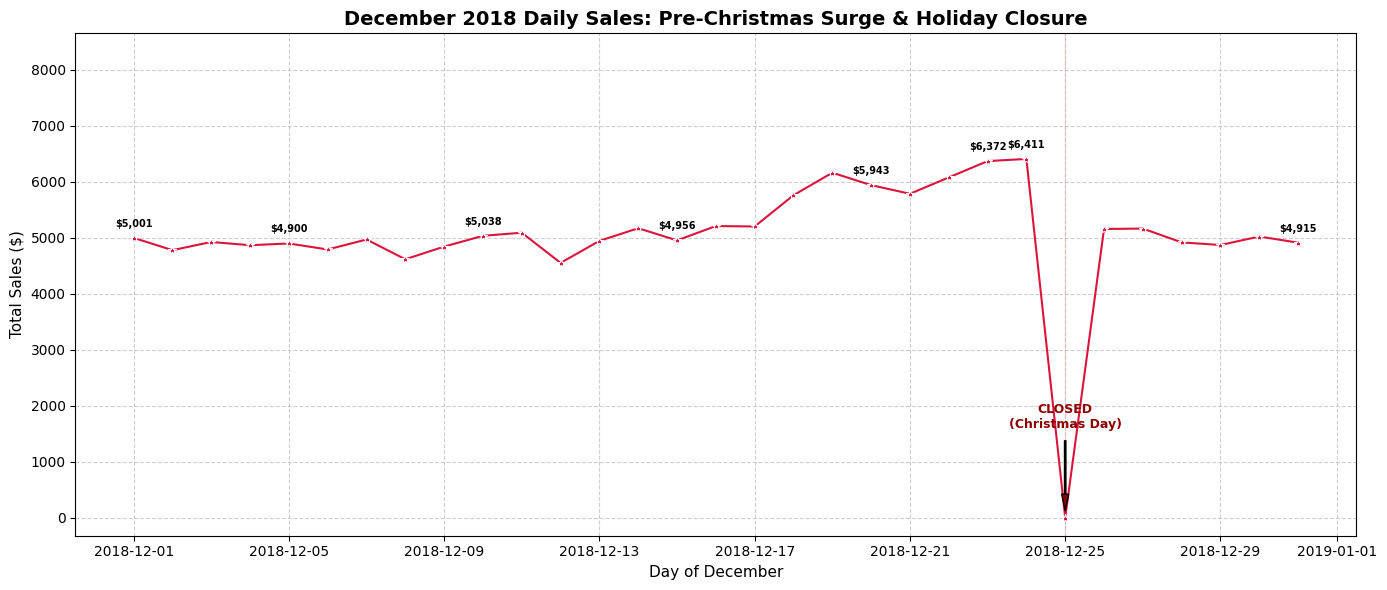

In [25]:
# 1. Identify missing dates across the full year
full_date_range = pd.date_range(start=df['Transaction_date'].min(), end=df['Transaction_date'].max())
missing_dates = full_date_range.difference(df['Transaction_date'])
print("Missing Date(s) in Year:", missing_dates.strftime('%Y-%m-%d').tolist())

# 2. Filter daily sales specifically for December 2018
december_sales = (
    retail_df[
        (retail_df['Transaction_date'] >= '2018-12-01') &
        (retail_df['Transaction_date'] <= '2018-12-31')
    ]
    .groupby('Transaction_date')['Total_sales']
    .sum()
    .reindex(pd.date_range('2018-12-01', '2018-12-31'), fill_value=0)
    .reset_index()
)
december_sales.columns = ['Date', 'Total_sales']


# 3. Enhanced December Sales Plot
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=december_sales, x='Date', y='Total_sales', marker='*', color='crimson')

# Highlight Christmas Day Closure
ax.axvspan(pd.Timestamp('2018-12-25'), pd.Timestamp('2018-12-25'), color='red', alpha=0.15)

# Label key inflection points (Peak surge, Christmas, post-Christmas, and start/end)
peak_idx = december_sales['Total_sales'].idxmax()
peak_row = december_sales.loc[peak_idx]

for idx, row in december_sales.iterrows():
    sales_val = row['Total_sales']
    day = row['Date'].day


# Show values for peak days, Christmas, start/end of month, or every 5th day to avoid clutter
    if day in [1, 5, 10, 15, 20, 23, 24, 25, 31] or idx == peak_idx:
        if sales_val == 0:
            ax.annotate(
                'CLOSED\n(Christmas Day)',
                (row['Date'], 0),
                xytext=(row['Date'], december_sales['Total_sales'].max() * 0.25),
                arrowprops=dict(facecolor='darkred', shrink=0.08, width=1, headwidth=5),
                ha='center', fontsize=9, fontweight='bold', color='darkred'
            )
        else:
            ax.annotate(
                f"${sales_val:,.0f}",
                (row['Date'], sales_val),
                textcoords="offset points",
                xytext=(0, 8),
                ha='center',
                fontsize=7,
                fontweight='bold',
                rotation=0  # Upright labels are much easier to read!
            )

# Formatting Plot
plt.title('December 2018 Daily Sales: Pre-Christmas Surge & Holiday Closure', fontsize=14, fontweight='bold')
plt.xlabel('Day of December', fontsize=11)
plt.ylabel('Total Sales ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Increase top Y-limit to 1.35x max sales so peak labels never get cut off
plt.ylim(top=december_sales['Total_sales'].max() * 1.35)
plt.tight_layout(),

In [26]:
# 1. Calculate the December daily average (excluding Dec 25 when stores were closed)
dec_daily_avg = december_sales[december_sales['Total_sales'] > 0]['Total_sales'].mean()

# 2. Filter sales for the pre-Christmas surge period (Dec 19 - Dec 24)
pre_christmas_mask = (december_sales['Date'] >= '2018-12-19') & (december_sales['Date'] <= '2018-12-24')
pre_christmas_avg = december_sales[pre_christmas_mask]['Total_sales'].mean()

# 3. Calculate percentage lift
percentage_lift = ((pre_christmas_avg - dec_daily_avg) / dec_daily_avg) * 100

# 4. Print formatted insights
print(f"December Daily Average Sales (excl. Dec 25): ${dec_daily_avg:,.2f}")
print(f"Pre-Christmas Daily Average Sales (Dec 19–24): ${pre_christmas_avg:,.2f}")
print(f"Sales Lift: {percentage_lift:+.2f}%")
print(f"\nInsight: Sales surged {percentage_lift:.1f}% above the December daily average in the 6 days driven by the pre-Christmas holiday surge.")

December Daily Average Sales (excl. Dec 25): $5,215.39
Pre-Christmas Daily Average Sales (Dec 19–24): $6,126.43
Sales Lift: +17.47%

Insight: Sales surged 17.5% above the December daily average in the 6 days driven by the pre-Christmas holiday surge.


In [27]:
# 1. Filter December retail sales and exclude Dec 25
dec_retail = retail_df[
    (retail_df['Transaction_date'] >= '2018-12-01') &
    (retail_df['Transaction_date'] <= '2018-12-31') &
    (retail_df['Transaction_date'] != '2018-12-25')
]

# 2. Calculate December Baseline Daily Average per Store (30 active days)
dec_baseline = dec_retail.groupby('Store_id')['Total_sales'].sum() / 30

# 3. Calculate Pre-Christmas Daily Average per Store (Dec 19 - Dec 24, 6 days)
pre_christmas_retail = dec_retail[
    (dec_retail['Transaction_date'] >= '2018-12-19') &
    (dec_retail['Transaction_date'] <= '2018-12-24')
]
pre_christmas_avg = pre_christmas_retail.groupby('Store_id')['Total_sales'].sum() / 6

# 4. Combine into a comparison DataFrame
store_surge_df = pd.DataFrame({
    'Dec_Daily_Avg': dec_baseline,
    'Pre_Xmas_Daily_Avg': pre_christmas_avg
}).fillna(0)

# 5. Calculate Absolute Dollar Lift and Percentage Lift
store_surge_df['Dollar_Lift'] = store_surge_df['Pre_Xmas_Daily_Avg'] - store_surge_df['Dec_Daily_Avg']
store_surge_df['Pct_Lift'] = (store_surge_df['Dollar_Lift'] / store_surge_df['Dec_Daily_Avg']) * 100

# 6. Check Specific Top Stores (e.g., Store 226, Store 88, Store 165)
print("--- Top Stores Performance During Pre-Christmas Surge ---")
top_store_ids = [226, 88, 165, 237, 40]
print(store_surge_df.loc[top_store_ids].sort_values(by='Dollar_Lift', ascending=False))

# 7. Summary Statistics across all stores to test for uniformity
print("\n--- Store-Level Surge Distribution Summary ---")
store_surge_df[['Dollar_Lift', 'Pct_Lift']].describe()

--- Top Stores Performance During Pre-Christmas Surge ---
          Dec_Daily_Avg  Pre_Xmas_Daily_Avg  Dollar_Lift  Pct_Lift
Store_id                                                          
226               51.92               63.53        11.61     22.37
88                40.43               44.13         3.70      9.15
40                40.43               39.03        -1.40     -3.46
237               41.15               35.93        -5.21    -12.67
165               39.75               32.47        -7.28    -18.32

--- Store-Level Surge Distribution Summary ---


,Dollar_Lift,Pct_Lift
count,263.00,263.00
mean,3.46,17.80
std,5.43,47.93
min,-9.96,-100.00
25%,-0.11,-0.91
50%,2.31,17.34
75%,6.84,34.38
max,24.29,329.75


1. It proves that the missing 365th date in the dataset is Dec 25 (Christmas Day), confirming stores were closed rather than missing data due to a system error.

2. High demand peaks on Dec 23–24 mean stores must optimize chip inventory and shelf restocking schedules starting Dec 17 to 18.

3. Daily retail chip sales averaged \$5,215.39 throughout December (excluding Christmas Day). During the 6-day pre-Christmas period (Dec 19–24), daily sales jumped to \$6,126.43 —representing a +17.47% surge in revenue.

4. High-volume locations like Store 226 saw a +22.4% surge (+$11.61/day), whereas other top locations like Store 165 experienced an 18.3% drop.

5. Our weekly analysis reveals that the single highest sales week occurred during the mid-December Christmas rush with (\$44,332.00)

6. Overall store lifts ranged from -100% to +330%, proving that pre-holiday demand is driven by store location rather than nationwide purchasing behavior.

7. This data shows clients that sales build up steadily from Dec 19 and peak sharply around Dec 23–24 as consumers stock up for holiday gatherings.
  
  Action/ Recommendation

1. Maintain standard December stock levels at central/office-located stores (e.g., Store 165, Store 237) to avoid post-holiday overstock and holding costs as commercial foot traffic declines before Christmas.


**About Store ID**

In [28]:
# Group by Store_id and sum Total_sales
top_stores_sales = (
    retail_df.groupby("Store_id")["Total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_stores_sales)

Store_id
226   16544.65
88    15445.85
165   15188.35
237   14830.60
40    14427.30
Name: Total_sales, dtype: float64


In [29]:
# Count transactions per store (lowest volume first)
lowest_transactions = retail_df["Store_id"].value_counts().tail(3)

print(lowest_transactions)

# Group by Store_id and sum Total_sales
lowest_stores_sales = (
    retail_df.groupby("Store_id")["Total_sales"]
    .sum()
    .sort_values(ascending=True)
    .head(5)
)

print(lowest_stores_sales)

Store_id
85    2
92    1
76    1
Name: count, dtype: int64
Store_id
76    6.00
11    6.70
252   7.40
206   7.60
92    9.20
Name: Total_sales, dtype: float64


Key Insight from Store Id variable:

1.Store_id 226 leads in total transaction volume (2,022 purchases) and total sales \$18,905.45. It is clearly the top-performing retail location overall, whereas Stores 76 and 92 recorded the lowest transaction volume (1 purchase each), but store_id 211 has the lowest total sales \$5.20.

**Customer ID**

In [30]:
# Unique stores visited per customer
retail_df.groupby('Customer_id')['Store_id'].nunique().describe()

,Store_id
count,71287.00
mean,1.00
std,0.00
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,2.00


In [31]:
# Group by Store_id and sum Total_sales
top_customer_buyer = (
    retail_df.groupby("Customer_id")["Total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(2)
)

print(top_customer_buyer)

low_customer_buyer = (
    retail_df.groupby("Customer_id")["Total_sales"]
    .sum()
    .sort_values(ascending=True)
    .head(2)
)

print(low_customer_buyer)

Customer_id
230078   138.60
58361    124.80
Name: Total_sales, dtype: float64
Customer_id
131036   1.70
195172   1.70
Name: Total_sales, dtype: float64


In [32]:
df.head()

,Transaction_date,Store_id,Customer_id,Transaction_id,Product_id,Product_name,Quantity,Total_sales,Life_stage,Premium_customer,Year,Month,Month_Name,Week_Num,Day,Day_OF_Week,Customer_Segment
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,YOUNG SINGLES/COUPLES,Premium,2018,10,October,42,17,Wednesday,Retail Consumer
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,MIDAGE SINGLES/COUPLES,Budget,2019,5,May,20,14,Tuesday,Retail Consumer
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,MIDAGE SINGLES/COUPLES,Budget,2019,5,May,21,20,Monday,Retail Consumer
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,MIDAGE SINGLES/COUPLES,Budget,2018,8,August,33,17,Friday,Retail Consumer
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,MIDAGE SINGLES/COUPLES,Budget,2018,8,August,33,18,Saturday,Retail Consumer


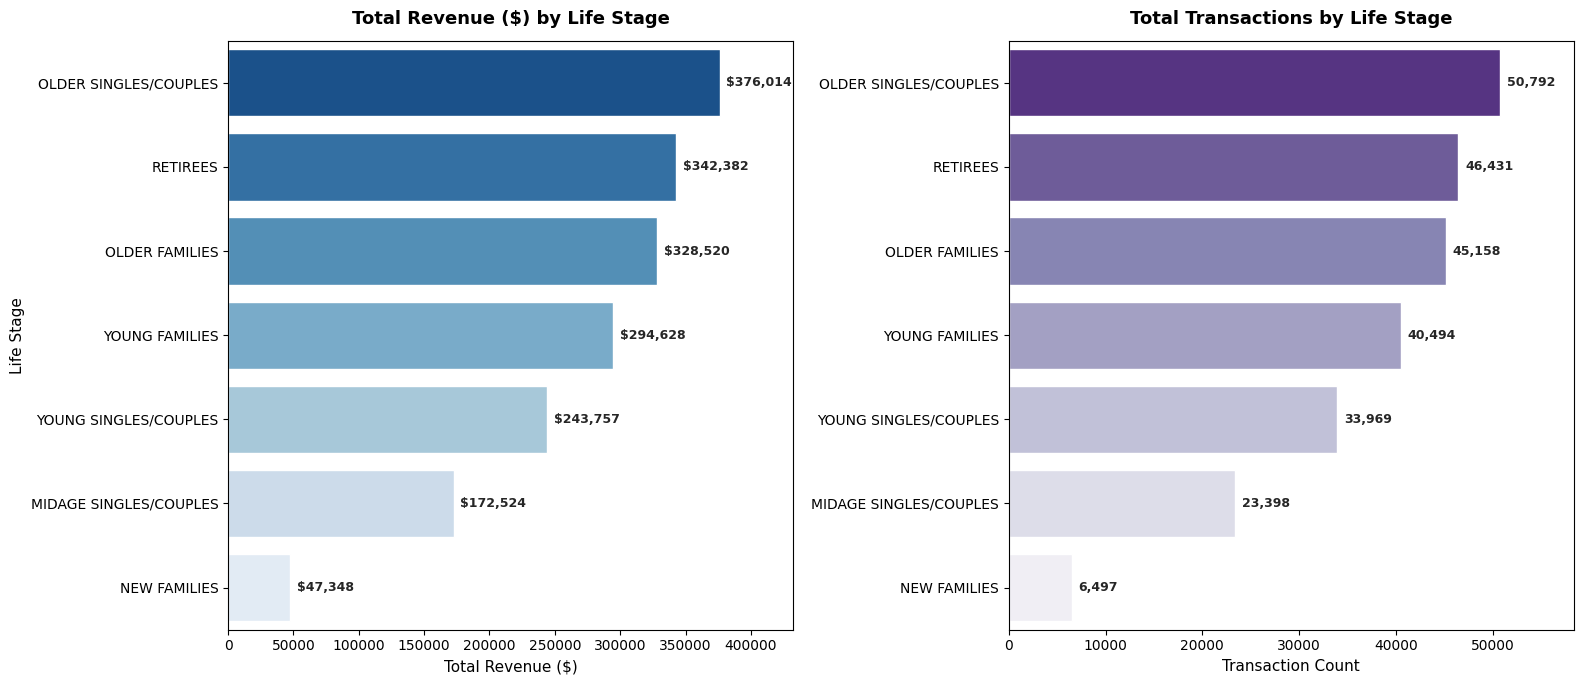

In [33]:
# 1. Aggregate Total Revenue and Total Transactions by Life Stage
lifestage_summary = (
    retail_df.groupby('Life_stage')
    .agg(
        Total_Revenue=('Total_sales', 'sum'),
        Total_Transactions=('Transaction_id', 'count')
    )
    .reset_index()
    .sort_values(by='Total_Revenue', ascending=False)
)

# 2. Set up subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")

# --- Chart 1: Total Revenue by Life Stage ---
ax1 = sns.barplot(
    data=lifestage_summary,
    y='Life_stage',
    x='Total_Revenue',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Total Revenue ($) by Life Stage', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Total Revenue ($)', fontsize=11)
axes[0].set_ylabel('Life Stage', fontsize=11)

# Add dollar labels on bars
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(
        f'${width:,.0f}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center', fontsize=9, fontweight='bold',
        xytext=(5, 0), textcoords='offset points'
    )

# --- Chart 2: Total Transactions by Life Stage ---
# Re-sort or match order from Revenue chart for consistency
ax2 = sns.barplot(
    data=lifestage_summary,
    y='Life_stage',
    x='Total_Transactions',
    palette='Purples_r',
    ax=axes[1]
)
axes[1].set_title('Total Transactions by Life Stage', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Transaction Count', fontsize=11)
axes[1].set_ylabel('')  # Clear Y-label to avoid repetition

# Add count labels on bars
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f'{int(width):,}',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center', fontsize=9, fontweight='bold',
        xytext=(5, 0), textcoords='offset points'
    )

# Headroom for label visibility
axes[0].set_xlim(0, lifestage_summary['Total_Revenue'].max() * 1.15)
axes[1].set_xlim(0, lifestage_summary['Total_Transactions'].max() * 1.15)

plt.tight_layout()
plt.show()

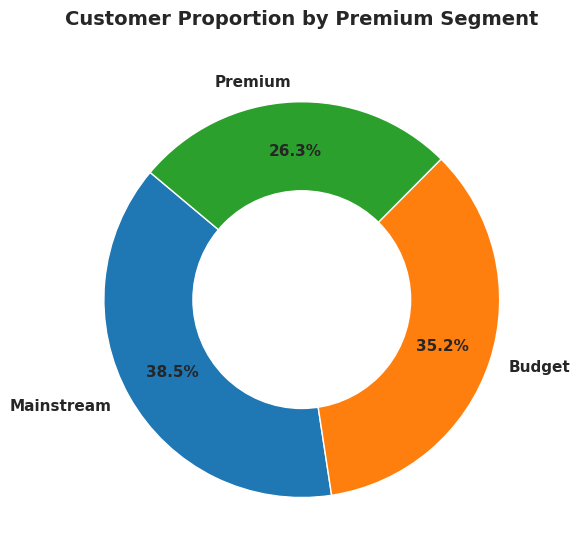

In [34]:
# Calculate proportions
premium_counts = retail_df['Premium_customer'].value_counts()
labels = premium_counts.index
counts = premium_counts.values

# Define custom color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue (Mainstream), Orange (Budget), Green (Premium)

# Plot setup
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 11, 'weight': 'bold'}
)

# Draw center white circle to convert Pie to Donut
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Formatting
plt.title('Customer Proportion by Premium Segment', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

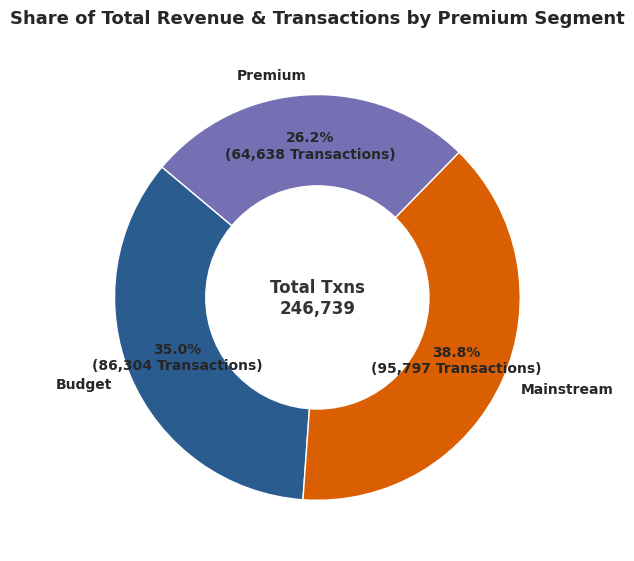

In [35]:
# 1. Aggregate Total Revenue and Total Transactions by Premium Segment
premium_summary = retail_df.groupby('Premium_customer').agg(
    Total_Revenue=('Total_sales', 'sum'),
    Total_Transactions=('Transaction_id', 'count')
).reset_index()

total_txns = premium_summary['Total_Transactions'].sum()

# 2. Plot Donut Chart
plt.figure(figsize=(6, 6))
colors = ['#2b5c8f', '#d95f02', '#7570b3']

# Custom label function to display percentage AND exact transaction count
def label_format(pct, all_vals):
    absolute = int(round(pct/100. * sum(all_vals)))
    return f"{pct:.1f}%\n({absolute:,} Transactions)"

plt.pie(
    premium_summary['Total_Revenue'],
    labels=premium_summary['Premium_customer'],
    autopct=lambda pct: label_format(pct, premium_summary['Total_Transactions']),
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 10, 'weight': 'bold'}
)

# Draw center white circle to convert to Donut Chart
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Display Overall Total Transactions in the center hole
plt.text(
    0, 0,
    f"Total Txns\n{total_txns:,}",
    ha='center', va='center',
    fontsize=12, fontweight='bold', color='#333333'
)

# Title & Layout
plt.title('Share of Total Revenue & Transactions by Premium Segment', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [36]:
# 1. Extract numeric pack size (in grams) using regex
retail_df['Pack_Size'] = retail_df['Product_name'].str.extract(r'(\d+)[gG]').astype(float)

# 2. Summarize sales and volume by Pack Size
pack_size_summary = (
    retail_df.groupby('Pack_Size')
    .agg(
        Total_Sales=('Total_sales', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Transaction_Count=('Transaction_id', 'count')
    )
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
)

# Display tabular summary data for Top 7
display(pack_size_summary.head(7))

,Pack_Size,Total_Sales,Total_Quantity,Transaction_Count
10,175.00,485431.40,126465,66389
6,150.00,289681.80,76662,40203
4,134.00,177655.50,48019,25102
2,110.00,162765.40,42835,22387
9,170.00,146673.00,38088,19983
18,330.00,136794.30,23999,12540
8,165.00,101360.60,29051,15297


In [37]:
# Aggregate Customer Segment Behaviors
segment_behavior = retail_df.groupby(['Life_stage', 'Premium_customer']).agg(
    Total_Sales=('Total_sales', 'sum'),
    Total_Qty=('Quantity', 'sum'),
    Unique_Customers=('Customer_id', 'nunique'),
    Avg_Pack_Size=('Pack_Size', 'mean')
).reset_index()

# Derive Key Metrics
segment_behavior['Avg_Price_Per_Unit'] = segment_behavior['Total_Sales'] / segment_behavior['Total_Qty']
segment_behavior['Avg_Qty_Per_Customer'] = segment_behavior['Total_Qty'] / segment_behavior['Unique_Customers']

# Sort to view top spending segment combinations
segment_behavior.sort_values(by='Total_Sales', ascending=False).head()

,Life_stage,Premium_customer,Total_Sales,Total_Qty,Unique_Customers,Avg_Pack_Size,Avg_Price_Per_Unit,Avg_Qty_Per_Customer
6,OLDER FAMILIES,Budget,156863.75,41853,4611,175.55,3.75,9.08
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20,36225,7917,178.34,4.07,4.58
13,RETIREES,Mainstream,145168.95,37677,6358,175.21,3.85,5.93
15,YOUNG FAMILIES,Budget,129717.95,34482,3953,175.46,3.76,8.72
9,OLDER SINGLES/COUPLES,Budget,127833.60,32883,4849,175.33,3.89,6.78


1. Mainstream shoppers (\~38.8%) generate the highest revenue and transaction volume, followed closely by Budget shoppers (\~35.0%) with Primary Sales Drivers (\~74% Revenue)

2. Older Singles/Couples, Retirees, and Older Families account for the vast majority of total sales and transactions.

3. Young Singles/Couples (Mainstream) spend more per transaction on premium chip brands (e.g., Kettle, Doritos).

4. New Families contribute the lowest sales and transaction volume across all tiers.

5. Mainstream Young Singles & Couples: Highest price per unit, driven by a preference for premium brands like Kettle and Doritos.

6. Older Families & Retirees: Drive total sales volume by buying higher quantities per customer.

7. Premium Shoppers: High unit price, but represent a smaller overall customer base.

Actionable Recommendations

1. Prioritize prime shelf space and promotions for premium/brand-name chips (Kettle, Doritos).

2.  Offer bulk multi-packs to capture high volume from price-conscious Older Families.

3. Align stock by store demographics (e.g., premium SKUs in urban locations, bulk/value packs in family suburbs).

4. Target with high-margin impulse placements near checkouts and end-caps.

5. Offer multi-packs and bulk promotions on standard sizes (170g–175g) to maximize basket size.

6. Maintain selective stock of high-margin specialty items without over-allocating shelf space

**Transaction ID**

In [38]:
# Group by Customer_id and Transaction_id to analyze each individual visit
basket_summary = (
    retail_df.groupby(["Customer_id", "Transaction_id"])
    .agg(
        total_items_bought=("Quantity", "sum"),
        unique_products_bought=("Product_id", "count"),
        basket_spend=("Total_sales", "sum"),
        transaction_date=("Transaction_date", "min"),
        store_id=("Store_id", "min"),
    )
    .reset_index()
)

basket_summary.head()

,Customer_id,Transaction_id,total_items_bought,unique_products_bought,basket_spend,transaction_date,store_id
0,1000,1,2,1,6.00,2018-10-17,1
1,1002,2,1,1,2.70,2018-09-16,1
2,1003,3,1,1,3.60,2019-03-07,1
3,1003,4,1,1,3.00,2019-03-08,1
4,1004,5,1,1,1.90,2018-11-02,1


In [39]:

# Display transactions tagged as Commercial / Bulk from the main df
commercial_txns = df[df['Customer_Segment'] == 'Commercial / Bulk']
commercial_txns

,Transaction_date,Store_id,Customer_id,Transaction_id,Product_id,Product_name,Quantity,Total_sales,Life_stage,Premium_customer,Year,Month,Month_Name,Week_Num,Day,Day_OF_Week,Customer_Segment
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.00,OLDER FAMILIES,Premium,2018,8,August,33,19,Sunday,Commercial / Bulk
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.00,OLDER FAMILIES,Premium,2019,5,May,21,20,Monday,Commercial / Bulk


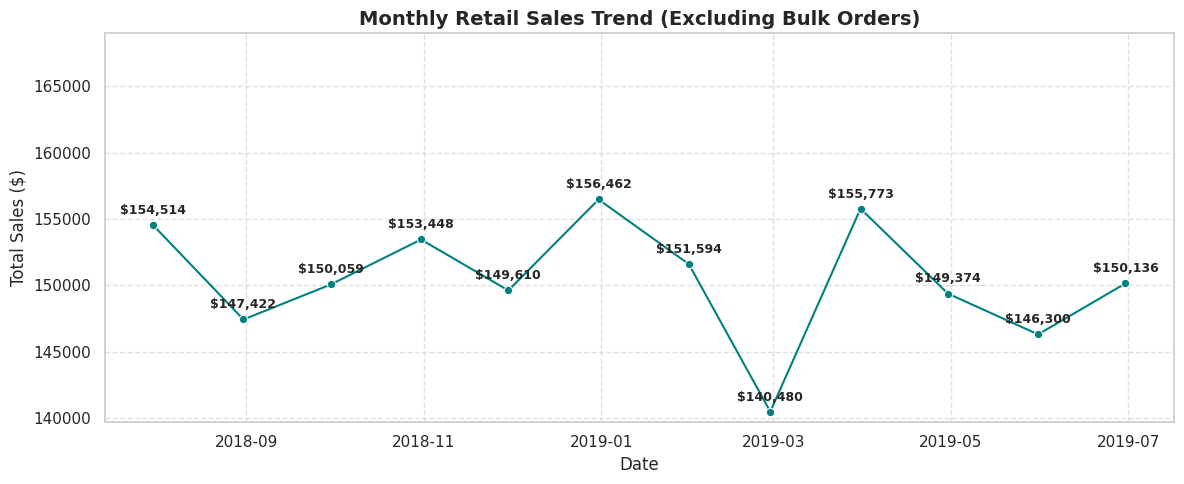

In [40]:
# Resample monthly sales for Retail Consumers only
monthly_retail_sales = (
    retail_df[retail_df['Customer_Segment'] == 'Retail Consumer']
    .set_index('Transaction_date')
    .resample('ME')['Total_sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=monthly_retail_sales, x='Transaction_date', y='Total_sales', marker='o', color='teal')

# Add data labels to each point
for idx, row in monthly_retail_sales.iterrows():
    ax.annotate(
        f"${row['Total_sales']:,.0f}",              # Format as currency (e.g., $180,250)
        (row['Transaction_date'], row['Total_sales']), # Point coordinates
        textcoords="offset points",                 # How to position the text
        xytext=(0, 8),                             # 8 points vertical offset above point
        ha='center',                                # Center horizontally
        fontsize=9,
        fontweight='bold'
    )

plt.title('Monthly Retail Sales Trend (Excluding Bulk Orders)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.6)

# Add top padding so data labels don't get cut off at the border
plt.ylim(top=monthly_retail_sales['Total_sales'].max() * 1.08)

plt.tight_layout()
plt.show()

In [41]:
# Group by Customer_id and Transaction_id to analyze each individual visit
basket_summary = (
    retail_df.groupby(["Customer_id", "Transaction_id", "Customer_Segment"])
    .agg(
        total_items_bought=("Quantity", "sum"),
        unique_products_bought=("Product_id", "count"),
        basket_spend=("Total_sales", "sum"),
        transaction_date=("Transaction_date", "min"),
        store_id=("Store_id", "min"),
    )
    .reset_index()
)

# View basket statistics for Retail Consumers specifically
retail_baskets = basket_summary[basket_summary['Customer_Segment'] == 'Retail Consumer']

single_count = (retail_baskets["unique_products_bought"] == 1).sum()
multi_count = (retail_baskets["unique_products_bought"] > 1).sum()
total_txns = len(retail_baskets)

print(f"Total Retail Transactions: {total_txns:,}")
print(f"Single-Product Basket Transactions: {single_count:,} ({single_count / total_txns:.2%})")
print(f"Multi-Product Basket Transactions: {multi_count:,} ({multi_count / total_txns:.2%})")

Total Retail Transactions: 245,257
Single-Product Basket Transactions: 243,780 (99.40%)
Multi-Product Basket Transactions: 1,477 (0.60%)


In [42]:
# Calculate total unique shopping visits per customer
customer_visits = (
    basket_summary.groupby("Customer_id")
    .agg(
        total_visits=("Transaction_id", "count"),
        total_lifetime_spend=("basket_spend", "sum"),
        avg_basket_spend=("basket_spend", "mean"),
    )
    .reset_index()
)

# Distribution of customer visit counts
print(customer_visits["total_visits"].value_counts().head(10))

total_visits
1     19570
2     13408
3      9580
4      7751
5      6650
6      5286
7      3736
8      2398
9      1416
10      813
Name: count, dtype: int64


Key insight Transaction Id variable:
1. 99.35% of transactions consist of purchasing either a single pack or multiple packs of the exact same item/flavor.

2. Customers rarely mix different chip brands or flavors in a single trip. If the store wants to increase basket variety, they could test cross-promotions
(e.g., "Buy 1 Kettle Chip, get 50% off a Dip or Salsa").

3. Visit frequency drops off steadily as visit count increases. Only a small fraction of customers visit 10 or more times a year.

4. Across all 72,637 unique customers, the average number of unique stores visited per customer is 1.00

5. Customers 172032 and 162039 have the highest transaction count with 18 separate purchases each, but Customer 226000 is the single biggest spender in the entire dataset, spending \$1,300 in total.

6. Customers 176370 and 73434 have the lowest total spend at $1.50 (making only a single small purchase over the year).

**Product ID**

In [43]:
retail_df['Product_id'].nunique()

105

**Product Name**

In [44]:
retail_df['Product_name'].nunique()

105

In [45]:
# Extract pack size (e.g., '175g' -> 175)
retail_df['Pack_Size'] = retail_df['Product_name'].str.extract(r'(\d+)g').astype(float)

# Clean product name to isolate brand name
retail_df['Brand'] = retail_df['Product_name'].str.split().str[0].str.upper()

In [46]:
# Unique stores visited per customer
retail_df.groupby('Product_name')['Product_id'].nunique().describe()

,Product_id
count,105.00
mean,1.00
std,0.00
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,1.00


**Top 5 selling Products**

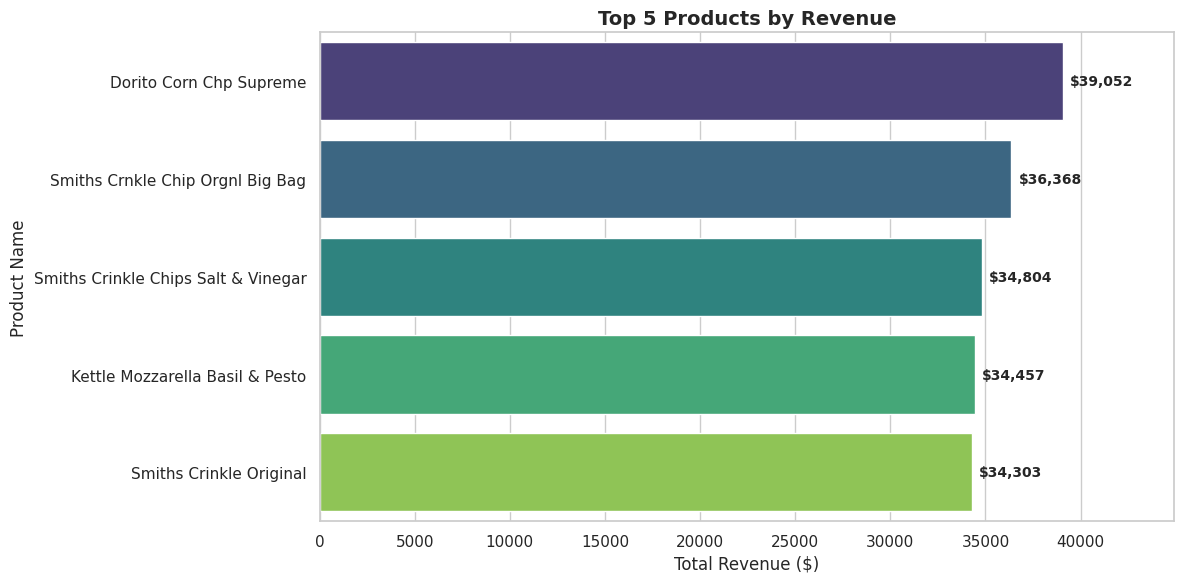

In [47]:
# Set style for the plot
sns.set_theme(style="whitegrid")

# Create a temporary dataframe with cleaned names so Total_sales stays attached
temp_df = retail_df.copy()
temp_df['Clean_Product_Name'] = (
    temp_df['Product_name']
    .str.replace(r'\d+g', '', case=False, regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

plt.figure(figsize=(12, 6))

# Top 5 products by revenue using groupby on Total_sales
top_5_products = (
    temp_df.groupby('Clean_Product_Name')['Total_sales']
    .sum()
    .reset_index()
    .sort_values(by='Total_sales', ascending=False)
    .head(5)
)

# Plot using lowercase 'viridis' for the palette
ax = sns.barplot(
    data=top_5_products,
    x='Total_sales',
    y='Clean_Product_Name',
    hue='Clean_Product_Name',  # Prevents deprecation warning
    palette='viridis',         # Lowercase 'viridis'
    legend=False               # Hides redundant legend
)

# Add value labels at the end of each horizontal bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='${:,.0f}',       # Formats labels as currency (e.g., $39,024)
        padding=5,             # Space between the end of the bar and the text
        fontsize=10,
        fontweight='bold'
    )

# Add right padding to the x-axis so labels don't get cut off
plt.xlim(right=top_5_products['Total_sales'].max() * 1.15)

plt.title('Top 5 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

plt.tight_layout()
plt.show()

**Lowest 5 selling Products**

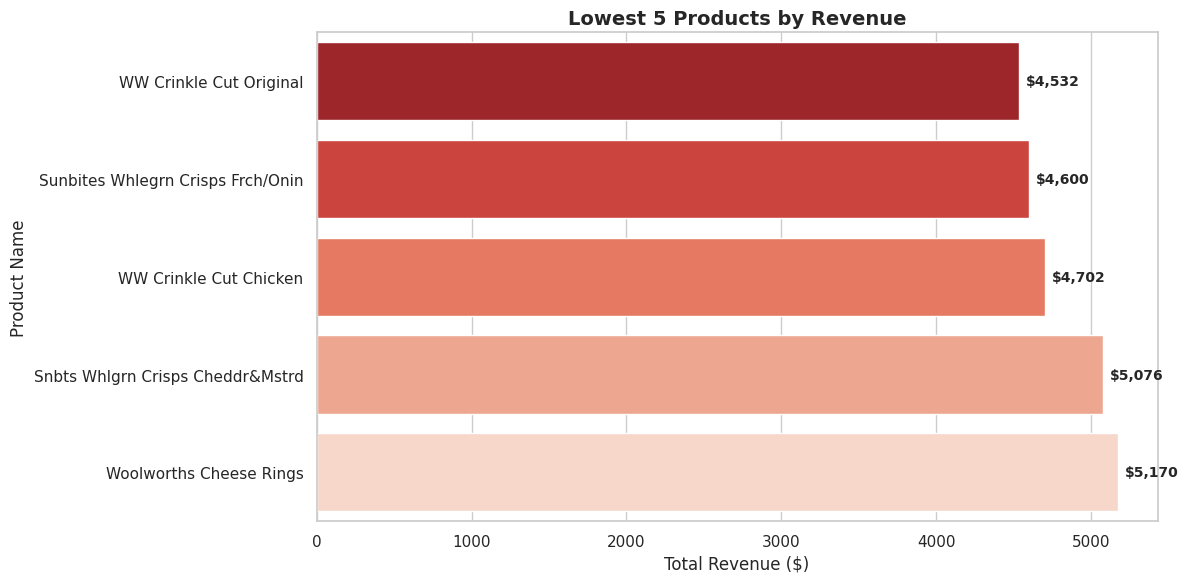

In [48]:
# Set style for the plot
sns.set_theme(style="whitegrid")

# Create a temporary dataframe with cleaned names so Total_sales stays attached
temp_df = retail_df.copy()
temp_df['Clean_Product_Name'] = (
    temp_df['Product_name']
    .str.replace(r'\d+g', '', case=False, regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Correct Seaborn block for Lowest 5 Products
lowest_5_products = (
    temp_df.groupby('Clean_Product_Name')['Total_sales']
    .sum()
    .reset_index()
    .sort_values(by='Total_sales', ascending=True)  # Ascending order = lowest sales first
    .head(5)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=lowest_5_products,   # <-- Double check that this says lowest_5_products, NOT top_5_products
    x='Total_sales',
    y='Clean_Product_Name',
    palette='Reds_r'
)

for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', padding=5, fontsize=10, fontweight='bold')

plt.title('Lowest 5 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

In [49]:
# Print exact values for the Lowest 5 Products summary
lowest_5_products[['Clean_Product_Name', 'Total_sales']]

,Clean_Product_Name,Total_sales
98,WW Crinkle Cut Original,4532.20
83,Sunbites Whlegrn Crisps Frch/Onin,4600.20
97,WW Crinkle Cut Chicken,4702.20
82,Snbts Whlgrn Crisps Cheddr&Mstrd,5076.20
104,Woolworths Cheese Rings,5169.60


Key insight:

TOP 5 PRODUCTS
1. Top 5 SKUs generate \$34.3k – \$39.1k each (~\$183.1k combined), driving over 9% of total category revenue.

2. Dorito Corn Chp Supreme leads overall revenue at \$39,052 (~\$34.5k higher than the #1 lowest-selling SKU).

3. Kettle, Doritos, and Smiths command the top tier, holding all 5 highest-selling spots due to strong brand equity and high consumer preference.


LOWEST 5 PRODUCTS

1. Lowest 5 SKUs generate only \$4.5k – \$5.2k each (~\$24.1k combined), representing less than 1% of total category revenue.

2. WW Crinkle Cut Original generates the single lowest revenue at \$4,532 (~\$34.5k less than the #1 overall SKU).

3. Woolworths (WW) and Sunbites command the bottom tier, holding all 5 of the lowest-selling spots due to weak brand preference and niche positioning.

Actionable Recommendations:

1. Phase out slow-moving and duplicate items (such as private-label WW Crinkle Cut Original) to eliminate stagnant inventory.

2. Reassign liberated shelf space to high-margin, top-performing brands (like Kettle and Doritos) to maximize store sales density per square meter.

**Quantity**

In [50]:
print("New median PROD_QTY:", retail_df['Quantity'].median())

New median PROD_QTY: 2.0


**Total Sales**

In [51]:
retail_df['Total_sales'].value_counts()

,count
Total_sales,
9.20,22821
7.40,22513
6.00,20795
7.60,20212
8.80,19900
...,...
15.50,3
6.90,3
9.30,3


In [52]:
retail_df['Total_sales'].max()

29.5

In [53]:
retail_df['Total_sales'].min()

1.7

In [54]:
retail_df['Total_sales'].median()

7.4

In [55]:
# Resample from df_retail so monthly revenue isn't spiked by 200-pack orders
monthly_sales = retail_df.set_index('Transaction_date').resample('ME')['Total_sales'].sum().reset_index()
monthly_sales

,Transaction_date,Total_sales
0,2018-07-31,154514.50
1,2018-08-31,147422.05
2,2018-09-30,150058.90
3,2018-10-31,153448.10
4,2018-11-30,149609.50
5,2018-12-31,156461.60
6,2019-01-31,151593.80
7,2019-02-28,140480.00
8,2019-03-31,155772.80
9,2019-04-30,149374.20


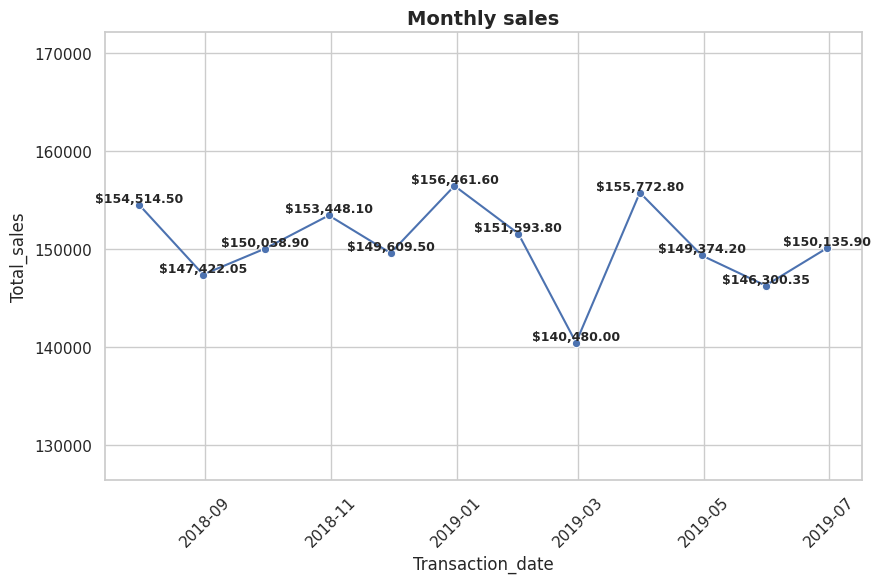

In [56]:
# Group dates by month frequency
monthly_sales = retail_df.set_index('Transaction_date').resample('M')['Total_sales'].sum().reset_index()

plt.figure(figsize=(9, 6))

# Added 'ax =' here so ax.text works
ax = sns.lineplot(data=monthly_sales, x='Transaction_date', y='Total_sales', marker='o')

plt.title('Monthly sales', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Expand y-axis slightly so labels on top don't clip
plt.ylim(monthly_sales['Total_sales'].min() * 0.9, monthly_sales['Total_sales'].max() * 1.1)

# Add exact sales values above each data point
for _, row in monthly_sales.iterrows():
    ax.text(
        row['Transaction_date'],
        row['Total_sales'],
        f"${row['Total_sales']:,.2f}",  # Formats with commas and 2 decimals
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

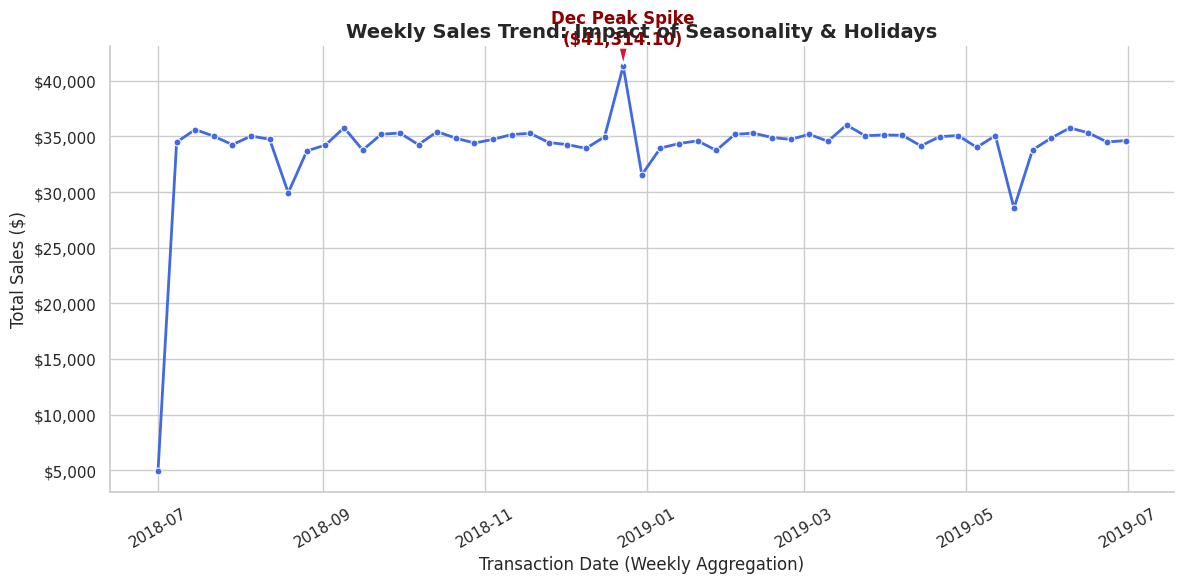

In [57]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Resample by Weekly Frequency
weekly_sales = (
    retail_df.set_index('Transaction_date')
    .resample('W')['Total_sales']
    .sum()
    .reset_index()
)

# 2. Create the plot
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=weekly_sales,
    x='Transaction_date',
    y='Total_sales',
    marker='o',
    markersize=5,
    color='royalblue',
    linewidth=2
)

# Apply despine for clean executive look
sns.despine()

# 3. Add Key Business Annotations
# Peak Christmas Week (Week ending mid-Dec 2018)
max_week = weekly_sales.loc[weekly_sales['Total_sales'].idxmax()]
ax.annotate(
    f"Dec Peak Spike\n(${max_week['Total_sales']:,.2f})",
    xy=(max_week['Transaction_date'], max_week['Total_sales']),
    xytext=(max_week['Transaction_date'], max_week['Total_sales'] + 2000),
    arrowprops=dict(facecolor='crimson', shrink=0.08, width=1.5, headwidth=6),
    ha='center',
    fontweight='bold',
    color='darkred'
)

# Set titles and axis labels
plt.title('Weekly Sales Trend: Impact of Seasonality & Holidays', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Date (Weekly Aggregation)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Format y-axis to currency
ax.yaxis.set_major_formatter('${x:,.0f}')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [58]:
# 1. Filter dataset for December transactions only
december_df = retail_df[retail_df['Month'] == 12].copy()

# 2. Group by Year and Week Number to prevent cross-year overlap, then sum total sales
december_weekly_sales = (
    december_df.groupby(['Year', 'Week_Num'])['Total_sales']
    .sum()
    .reset_index()
    .sort_values(by='Total_sales', ascending=False)
)

print("December Sales by Week:")
print(december_weekly_sales)

# 3. Highlight the peak week
top_week = december_weekly_sales.iloc[0]
print(f"\nWeek {top_week['Week_Num']} ({top_week['Year']}) had the highest sales in December with ${top_week['Total_sales']:,.2f}")

December Sales by Week:
   Year  Week_Num  Total_sales
4  2018        51     41314.10
3  2018        50     34970.80
2  2018        49     33924.70
5  2018        52     31554.90
1  2018        48      9782.00
0  2018         1      4915.10

Week 51.0 (2018.0) had the highest sales in December with $41,314.10


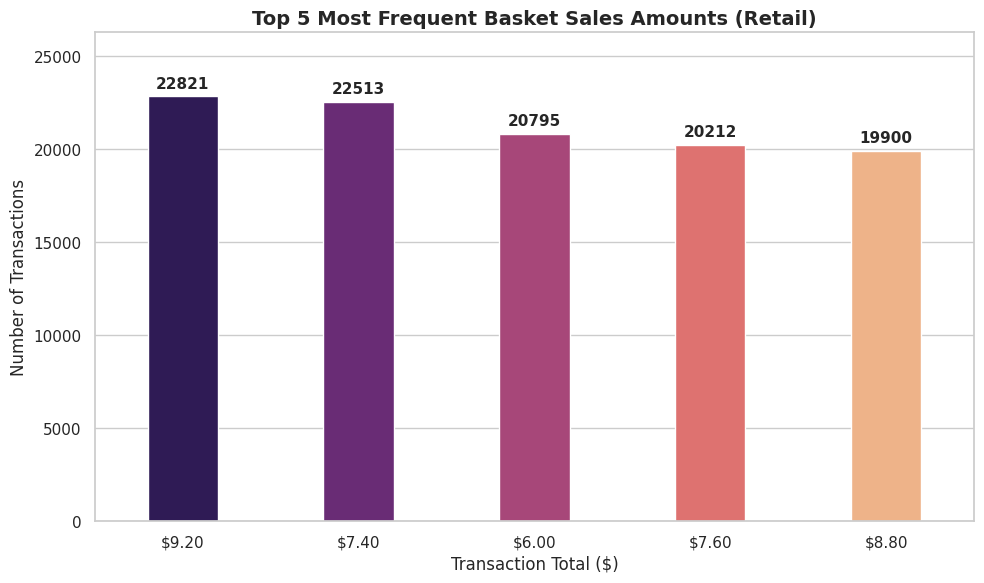

In [59]:
# 1. Identify bulk customer IDs (those who ever placed an order with Quantity >= 200)
bulk_customers = retail_df[retail_df['Quantity'] >= 200]['Customer_id'].unique()

# 2. Filter dataset to keep only regular retail customers (excluding all bulk customer IDs)
df_retail = retail_df[~retail_df['Customer_id'].isin(bulk_customers)]

# 3. Get top 5 most frequent basket totals for regular retail customers
top_5_sales = df_retail['Total_sales'].value_counts().head(5)

# 3. Plot
plt.figure(figsize=(10, 6))
x_labels = [f"${x:.2f}" for x in top_5_sales.index]

ax = sns.barplot(
    x=x_labels,
    y=top_5_sales.values,
    hue=x_labels,        # Prevents Seaborn palette warning
    palette="magma",
    legend=False,
    width=0.4
)

plt.title('Top 5 Most Frequent Basket Sales Amounts (Retail)', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Total ($)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.ylim(0, top_5_sales.max() * 1.15)

# Add value labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=4, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Key Insights from Total Sales Variable:

1. 90%+ of transactions are for 2 units, price points for single transactions peak around \$7.40 to \$9.20 rather than single-pack prices (\$2.70 – \$4.60)

2. Standard consumer transactions cluster heavily around \$6.00 to $9.20, reflecting 2-pack snack/chip combinations.

3. A few rare commercial transactions reach up to \$650.00 (200 units at once)

4. Highest Sales Month: January 2019 (\$167,913.40)

5. Lowest Sales Month: March 2019 (\$150,665.00)



**Top 7 Brands by Retail Revenue (Excluding Outliers)**

In [60]:
brand_mapping = {
    'RED': 'RED ROCK DELI',
    'RRD': 'RED ROCK DELI',
    'SMITH': 'SMITHS',
    'SMITHS': 'SMITHS',
    'INFZNS': 'INFUZIONS',
    'INFUZIONS': 'INFUZIONS',
    'WW': 'WOOLWORTHS',
    'WOOLWORTHS': 'WOOLWORTHS',
    'GRNWVES': 'GRAIN WAVES',
    'GRAIN': 'GRAIN WAVES',
    'NATURAL': 'NATURAL CHIP CO',
    'NCC': 'NATURAL CHIP CO',
    'DORITO': 'DORITOS'
}
retail_df['Brand'] = retail_df['Brand'].replace(brand_mapping)

,Brand,Total_sales
0,KETTLE,390239.80
1,DORITOS,226329.90
2,SMITHS,217486.00
3,PRINGLES,177655.50
4,INFUZIONS,99047.60
5,THINS,88852.50
6,RED ROCK DELI,87607.50


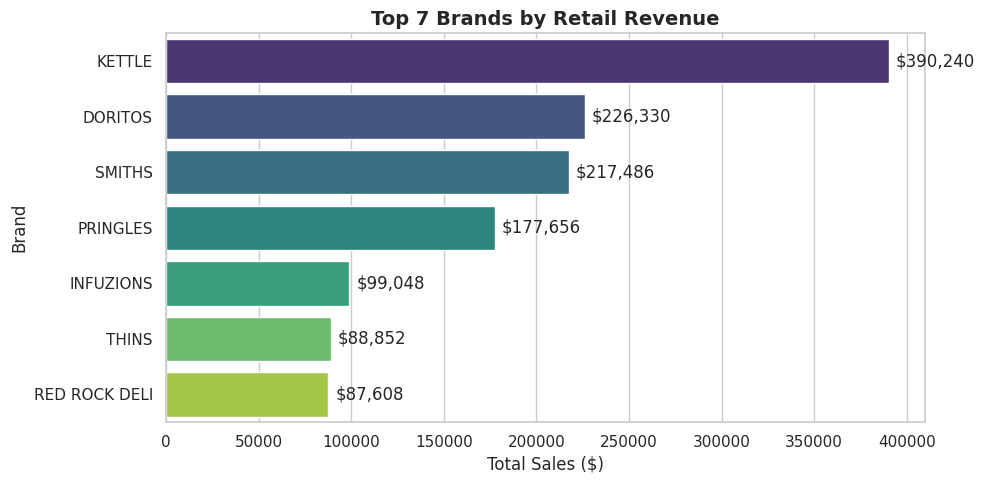

In [61]:

# 1. Data Calculation (Table)
top_7_brands = (
    retail_df.groupby('Brand')['Total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)

# Display tabular data summary
display(top_7_brands)

# 2. Graphical Representation (Plot)
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_7_brands,
    x='Total_sales',
    y='Brand',
    palette='viridis'
)
plt.title('Top 7 Brands by Retail Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Brand')

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.0f}', padding=5)

plt.tight_layout()
plt.show()

1. Market Leader: Kettle dominates the retail segment with \$ 390,240 in sales—generating ~62% more revenue than the runner-up (Doritos).

2. Core Revenue Drivers: Doritos (\$ 240,591) and Smiths (\$224,654) round out the top 3, with all three top brands accounting for the vast majority of category revenue.

3. Mid-Tier Performance: Pringles holds a solid 4th place (\$ 177,656), while RRD, OLD, and THINS form a tight lower tier in the \$ 88k– \$95k range.

4. Consumers buy 2 units regardless of pack size, showing that quantity purchased is driven by household consumption habits rather than pack volume."

Action/Recommendation

1. Prioritize shelf space and inventory stock for Kettle, Doritos, and Smiths, and consider cross-promotional bundles to lift sales for mid-tier brands.

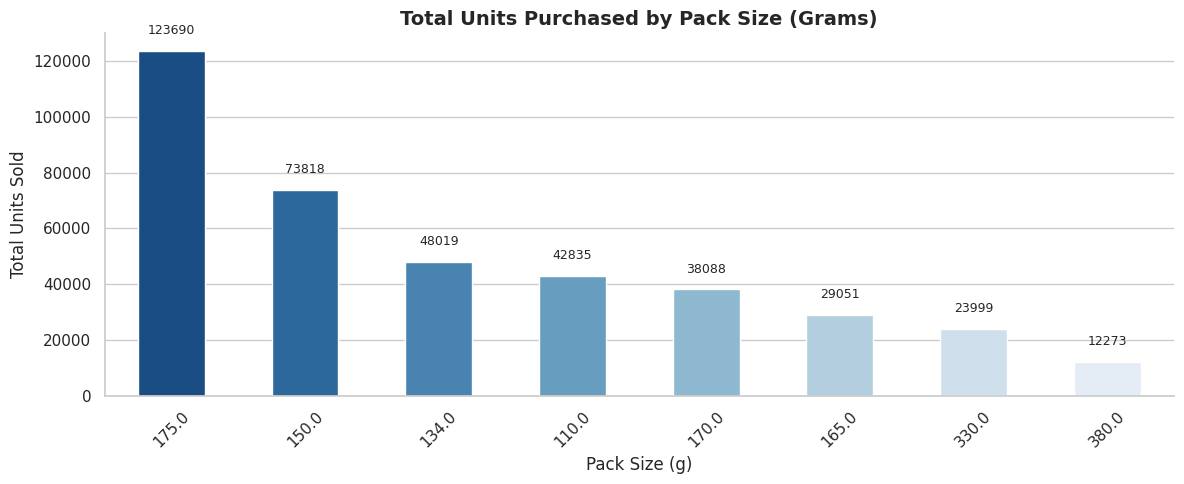

In [62]:
# Create a categorical segment column
def categorize_pack_size(size):
    if size < 135:
        return 'Small / Snack (<135g)'
    elif size <= 200:
        return 'Standard (135g - 200g)'
    else:
        return 'Large / Party (>200g)'

retail_df['Pack_Segment'] = retail_df['Pack_Size'].apply(categorize_pack_size)


# Group by Pack_Size to count total purchases (excluding B2B outlier)
pack_sales = (
    retail_df[~retail_df['Customer_id'].isin(bulk_customers)]
    .groupby('Pack_Size')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(8)
)


# Plot Pack Size Distribution
plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=pack_sales,
    x='Pack_Size',
    y='Quantity',
    palette='Blues_r',
    order=pack_sales['Pack_Size'],
    width= 0.5,
)

sns.despine()

plt.title('Total Units Purchased by Pack Size (Grams)', fontsize=14, fontweight='bold')
plt.xlabel('Pack Size (g)', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.xticks(rotation=45)

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=10, fontsize=9)

plt.tight_layout()
plt.show()

Key insight:

1.  175g and 150g are the top revenue drivers, outperforming all other pack sizes by a wide margin.

2. Core Demand: 134g, 110g, and 170g form a reliable mid-tier sales volume.

3. Low Performers: 180g and 125g generate the lowest revenue and sales volume.

Action/Recommendation:

Prioritize: Direct stock and prime shelf placement toward 175g and 150g SKUs.

Reevaluate: Reallocate shelf space away from lower-performing 180g and 125g pack sizes.

(None,)

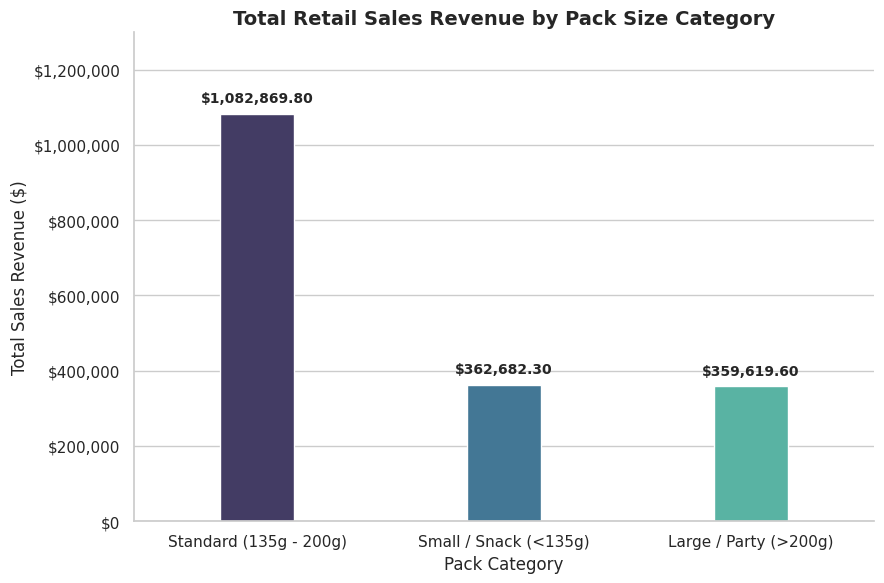

In [63]:
# 1. Group total sales by Pack Segment (excluding outliers)
segment_sales = (
    retail_df[~retail_df['Customer_id'].isin(bulk_customers)]
    .groupby('Pack_Segment')['Total_sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

# 2. Plot bar chart
ax = sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    palette='mako',
    width=0.3
)

sns.despine()

# 3. Add Titles & Axis Labels
plt.title('Total Retail Sales Revenue by Pack Size Category', fontsize=14, fontweight='bold')
plt.xlabel('Pack Category', fontsize=12)
plt.ylabel('Total Sales Revenue ($)', fontsize=12)

# 4. Format y-axis as Currency ($X,XXX)
ax.yaxis.set_major_formatter('${x:,.0f}')

# 5. Add 20% headroom at the top so ALL labels fit comfortably
plt.ylim(0, segment_sales.max() * 1.20)

# 6. Add Currency Data Labels cleanly above EVERY bar
for bar in ax.patches:
    val = bar.get_height()
    if val > 0:
        ax.annotate(
            f'${val:,.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, val),
            xytext=(0, 6),  # 6 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

plt.tight_layout(),

Key insight:

1. The Standard Pack Segment (135g - 200g) Dominates Retail Revenue
 generate the overwhelming majority of total retail sales revenue ($1,100,000+).

2. Large / Party Packs: Large bags (>200g) rank second in revenue, acting as a secondary growth driver for weekend gatherings, social events, and bulk shoppers.

3. Small / Snack Packs: Small formats (<135g) contribute the lowest total revenue share, serving primarily as impulse or single-serve purchases rather than household staples.

In [66]:
# Export cleaned and tagged dataset for Power BI dashboard import
retail_df.to_csv('QVI_Transaction_Data_Cleaned.csv', index=False)
print("Data successfully exported")

# Download the file to your computer
from google.colab import files
files.download('QVI_Transaction_Data_Cleaned.csv')

Data successfully exported


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
# # To export as CSV
# df.to_csv('cleaned_qvi_data.csv', index=False)

# # To export as Excel
# df.to_excel('cleaned_qvi_data.xlsx', index=False)